---
title: "Lecture 24: Krylov methods, GMRES"
author: "Jamie Haddock"
format: 
    revealjs:
        output-file: Lecture24_slides
        slide-number: true
        preview-links: auto
        logo: figs/hmc.png
        css: input/slides.css
        incremental: true
        smaller: true
        code-fold: true
        embed-resources: true
    html: 
        code-fold: true
        embed-resources: true
    pdf:
        documentclass: article
        toc: true
        number-sections: true
        geometry:
          - top=1in
          - left=1in
          - bottom=1in
          - right=1in
format-links: false
jupyter: julia-1.9
filters: 
  - input/remove-pause.lua
execute:
  echo: true
  eval: true
---

# Krylov subspaces

The power and inverse iterations have a flaw that seems obvious once it is pointed out. Given a seed vector $\mathbf{u}$, they produce a sequence of vectors $\mathbf{u}_1,\mathbf{u}_2,\ldots$ that are scalar multiples of $\mathbf{u},\mathbf{A}\mathbf{u},\mathbf{A}^{2}\mathbf{u},\ldots$, but only the most recent vector is used to produce an eigenvector estimate. 

. . .

It stands to reason that we could do no worse, and perhaps much better, if we searched among all linear combinations of the vectors seen in the past. In other words, we seek a solution in the range (column space) of the matrix

$$\begin{bmatrix}
  \mathbf{u} & \mathbf{A}\mathbf{u} & \mathbf{A}^{2} \mathbf{u} & \cdots & \mathbf{A}^{m-1} \mathbf{u}
\end{bmatrix}.$$

. . .

::: {.callout-note icon=false}
## Definition: Krylove matrix and subspace
Given $n\times n$ matrix $\mathbf{A}$ and $n$-vector $\mathbf{u}$, the $m$th **Krylov matrix** is the $n\times m$ matrix above. The range (i.e., column space) of this matrix is the $m$th **Krylov subspace** $\mathcal{K}_m$.
:::

. . .

In general, we expect that the dimension of the Krylov subspace $\mathcal{K}_m$, which is the rank of $\mathbf{K}_m$, equals $m$, though it may be smaller.

## Properties

As we have seen with the power iteration, part of the appeal of the Krylov matrix is that it can be generated in a way that fully exploits the sparsity of $\mathbf{A}$, simply through repeated matrix-vector multiplication. Furthermore, we have some important mathematical properties.

. . .

::: {.callout-warning icon=false}
## Theorem: 
Suppose $\mathbf{A}$ is $n\times n$, $0<m<n$, and a vector $\mathbf{u}$ is used to generate Krylov subspaces. If $\mathbf{x}\in\mathcal{K}_m$, then the following hold:

1. $\mathbf{x} = \mathbf{K}_m \mathbf{z}$ for some $\mathbf{z}\in\mathbb{C}^m$.
2. $\mathbf{x} \in \mathcal{K}_{m+1}$.
3. $\mathbf{A}\mathbf{x} \in \mathcal{K}_{m+1}$.
:::

<details><summary>Proof:</summary> 

If $\mathbf{x}\in\mathcal{K}_m$, then for some coefficients $c_1,\ldots,c_m$,
$\mathbf{x} = c_1 \mathbf{u} + c_2 \mathbf{A} \mathbf{u} + \cdots + c_m \mathbf{A}^{m-1} \mathbf{u}.$
Thus let $\mathbf{z}= \begin{bmatrix} c_1 & \cdots & c_m \end{bmatrix}^T$. 

Also $\mathbf{x}\in\mathcal{K}_{m+1}$, as we can add zero times $\mathbf{A}^{m}\mathbf{u}$ to the sum. 

Finally, $\mathbf{A}\mathbf{x} = c_1 \mathbf{A} \mathbf{u} + c_2 \mathbf{A}^{2} \mathbf{u} + \cdots + c_m \mathbf{A}^{m} \mathbf{u} \in \mathcal{K}_{m+1}.$
</details>

## Dimension reduction

The problems $\mathbf{A}\mathbf{x}=\mathbf{b}$ and $\mathbf{A}\mathbf{x}=\lambda\mathbf{x}$ are statements about a very high-dimensional space $\mathbb{C}^n$. One way to approximate them is to replace the full $n$-dimensional space with a much lower-dimensional $\mathcal{K}_m$ for $m\ll n$. This is the essence of the Krylov subspace approach.

. . .

For instance, we can interpret $\mathbf{A}\mathbf{x}_m\approx \mathbf{b}$ in the sense of linear least-squares—that is, to let $\mathbf{x}=\mathbf{K}_m\mathbf{z}$,

$$\min_{\mathbf{x}\in\mathcal{K}_m} \|  \mathbf{A}\mathbf{x}-\mathbf{b} \|
= \min_{\mathbf{z}\in\mathbb{C}^m} \| \mathbf{A}(\mathbf{K}_m\mathbf{z})-\mathbf{b} \|
= \min_{\mathbf{z}\in\mathbb{C}^m} \| (\mathbf{A}\mathbf{K}_m)\mathbf{z}-\mathbf{b} \|.$$

. . .

The natural seed vector for $\mathcal{K}_m$ in this case is the vector $\mathbf{b}$. We take one precaution: because the vectors $\mathbf{A}^{k}\mathbf{b}$ may become very large or small in norm, we normalize after each multiplication by $\mathbf{A}$, just as we did in the power iteration.

---

In [2]:
# | echo: false
using LinearAlgebra
using Plots

In [3]:
# define a triangular matrix with known eigenvalues, and a random vector b
λ = @. 10 + (1:100)
A = triu(rand(100,100),1) + diagm(λ)
b = rand(100);

In [4]:
# build up the first ten Krylov matrices iteratively, using renormalization 
# after each matrix-vector multiplication
Km = [b zeros(100,29)]
for m in 1:29      
    v = A*Km[:,m]
    Km[:,m+1] = v/norm(v)
end

In [5]:
# solve least-squares problems for Krylov matrices of increasing dimension, 
# recording the residual
resid = zeros(30)
for m in 1:30  
    z = (A*Km[:,1:m])\b
    x = Km[:,1:m]*z
    resid[m] = norm(b-A*x)
end

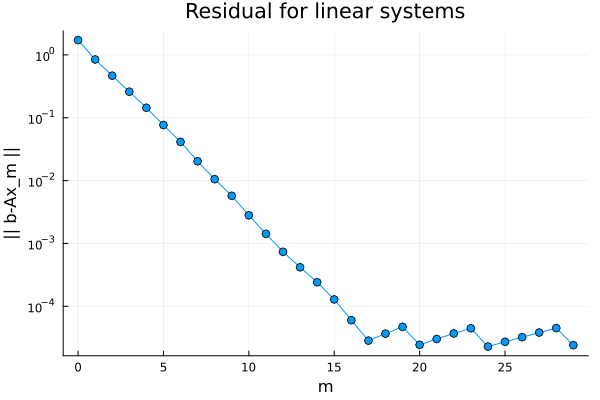

In [9]:
# linear system approximations show smooth linear convergence at first, but 
# the convergence stagnates after only a few digits have been found
plot(0:29,resid,m=:o,
    xaxis=("m"),yaxis=(:log10,"|| b-Ax_m ||"), 
    title="Residual for linear systems",leg=:none)

## The Arnoldi iteration

The breakdown of convergence in this demo is due to a critical numerical defect in our approach: the columns of the Krylov matrix increasingly become parallel to the dominant eigenvector, as the convergence of the Power Iteration predicts. 

. . .

As we saw when solving least-squares problems, near-parallel columns in the matrix defining a least-squares problem create the potential for numerical cancellation. This manifests as a large condition number for $\mathbf{K}_m$ as $m$ grows, eventually creating excessive error when solving the least-squares system.

. . .

The polar opposite of an ill-conditioned basis for $\mathcal{K}_m$ is an orthonormal one. Suppose we had a thin QR factorization of $\mathbf{K}_m$:

$$\mathbf{K}_m  = \mathbf{Q}_m \mathbf{R}_m
   =
  \begin{bmatrix}
    \mathbf{q}_1& \mathbf{q}_2 & \cdots & \mathbf{q}_m
  \end{bmatrix}
  \begin{bmatrix}
    R_{11} & R_{12} & \cdots & R_{1m} \\
    0 & R_{22} & \cdots & R_{2m} \\
    \vdots & & \ddots & \\
    0 & 0 & \cdots & R_{mm}
  \end{bmatrix}.$$

. . .

The vectors $\mathbf{q}_1,\ldots,\mathbf{q}_m$ are the orthonormal basis we seek for $\mathcal{K}_m$.

---

By the previous theorem, we know that $\mathbf{A}\mathbf{q}_m \in \mathcal{K}_{m+1}$, and therefore

$$\mathbf{A} \mathbf{q}_m = H_{1m} \, \mathbf{q}_1 + H_{2m} \, \mathbf{q}_2 + \cdots + H_{m+1,m}\,\mathbf{q}_{m+1}$$

for some choice of the $H_{ij}$. 

. . .

Note that by using orthonormality, we have

$$\mathbf{q}_i^* (\mathbf{A}\mathbf{q}_m) = H_{im},\qquad i=1,\ldots,m.$$

. . .

Since we started by assuming that we know $\mathbf{q}_1,\ldots,\mathbf{q}_m$, the only unknowns in the equation above are $H_{m+1,m}$ and $\mathbf{q}_{m+1}$. But they appear only as a product, and we know that $\mathbf{q}_{m+1}$ is a *unit* vector, so they are uniquely defined (up to sign) by the other terms in the equation.

---

**Algorithm: Arnoldi iteration**

Given matrix $\mathbf{A}$ and vector $\mathbf{u}$:

1. Let $\mathbf{q}_1= \mathbf{u} \,/\, \| \mathbf{u}\|$.
2. For $m=1,2,\ldots$
    
    a. Use $\mathbf{q}_i^* (\mathbf{A}\mathbf{q}_m) = H_{im}$ to find $H_{im}$ for $i=1,\ldots,m$.
    
    b. Let $\mathbf{v} = (\mathbf{A} \mathbf{q}_m) - H_{1m} \,\mathbf{q}_1 - H_{2m}\, \mathbf{q}_2 - \cdots - H_{mm}\, \mathbf{q}_m.$

    c. Let $H_{m+1,m}=\|\mathbf{v}\|$.
    
    d. Let $\mathbf{q}_{m+1}=\mathbf{v}\,/\,H_{m+1,m}$.

. . .

The Arnoldi iteration finds nested orthonormal bases for a family of nested Krylov subspaces.

---

In [16]:
A = rand(1.:9.,6,6)

6×6 Matrix{Float64}:
 5.0  8.0  9.0  5.0  4.0  9.0
 8.0  2.0  6.0  7.0  4.0  5.0
 8.0  8.0  2.0  6.0  9.0  1.0
 9.0  9.0  8.0  3.0  8.0  9.0
 2.0  6.0  8.0  6.0  8.0  6.0
 6.0  9.0  2.0  7.0  5.0  9.0

In [17]:
# the seed vector we choose here determines the first member of the orthonormal basis
u = randn(6)
Q = u/norm(u);

In [ ]:
# multiplication by A gives us a new vector in K_2
Aq = A*Q[:,1];

In [19]:
# orthonormalization
v = Aq - dot(Q[:,1],Aq)*Q[:,1]
Q = [Q v/norm(v)];
Aq = A*Q[:,2]
v = Aq - dot(Q[:,1],Aq)*Q[:,1] - dot(Q[:,2],Aq)*Q[:,2]
Q = [Q v/norm(v)];

In [ ]:
# at every step, Q_m is an ONC matrix
@show opnorm( Q'*Q - I );

opnorm(Q' * Q - I) = 4.2663718194431867e-16


In [21]:
# Q_m spans the same space as the three-dimensional Krylov matrix
K = [ u A*u A*A*u ];
@show rank( [Q K] );

rank([Q K]) = 3


## Key identity

Up to now we have focused only on finding the orthonormal basis that lies in the columns of $\mathbf{Q}_m$. But the $H_{ij}$ values found during the iteration are also important. Stacking the vectors $\mathbf{A}\mathbf{q}_i$ into a single matrix yields

$$\begin{split}
  \mathbf{A}\mathbf{Q}_m &= \begin{bmatrix}
    \mathbf{A}\mathbf{q}_1 & \cdots \mathbf{A}\mathbf{q}_m
  \end{bmatrix}\\
  & = \begin{bmatrix}
    \mathbf{q}_1 & \mathbf{q}_2 & \cdots & \mathbf{q}_{m+1}
  \end{bmatrix}\:  \begin{bmatrix}
    H_{11} & H_{12} & \cdots & H_{1m} \\
    H_{21} & H_{22} & \cdots & H_{2m} \\
    & H_{32} & \ddots & \vdots \\
    & & \ddots & H_{mm} \\
    & & & H_{m+1,m}
\end{bmatrix} = \mathbf{Q}_{m+1} \mathbf{H}_m.
\end{split}$$

This result is fundamental to Krylov subspace methods.

. . .

::: {.callout-note icon=false}
## Definition: Upper Hessenberg matrix
A matrix $\mathbf{H}$ is **upper Hessenberg** if $H_{ij}=0$ whenever $i>j+1$.
:::

---

In [22]:
"""
    arnoldi(A,u,m)

Perform the Arnoldi iteration for `A` starting with vector `u`, out
to the Krylov subspace of degree `m`. Returns the orthonormal basis
(`m`+1 columns) and the upper Hessenberg `H` of size `m`+1 by `m`.
"""
function arnoldi(A,u,m)
    n = length(u)
    Q = zeros(n,m+1)
    H = zeros(m+1,m)
    Q[:,1] = u/norm(u)
    for j in 1:m
        # Find the new direction that extends the Krylov subspace.
        v = A*Q[:,j]
        # Remove the projections onto the previous vectors.
        for i in 1:j
            H[i,j] = dot(Q[:,i],v)
            v -= H[i,j]*Q[:,i]
        end
        # Normalize and store the new basis vector.
        H[j+1,j] = norm(v)
        Q[:,j+1] = v/H[j+1,j]
    end
    return Q,H
end

arnoldi

# GMRES

The most important use of the Arnoldi iteration is to solve the square linear system $\mathbf{A}\mathbf{x}=\mathbf{b}$. 

. . .

In our earlier demo, we attempted to replace the linear system $\mathbf{A}\mathbf{x}=\mathbf{b}$ by the lower-dimensional approximation

$$\min_{\mathbf{x}\in \mathcal{K}_m} \|  \mathbf{A}\mathbf{x}-\mathbf{b}  \| = \min_{\mathbf{z}\in\mathbb{C}^m} \|   \mathbf{A}\mathbf{K}_m\mathbf{z}-\mathbf{b}  \|,$$

where $\mathbf{K}_m$ is the Krylov matrix generated using $\mathbf{A}$ and the seed vector $\mathbf{b}$. 

. . .

This method was unstable due to the poor conditioning of $\mathbf{K}_m$, which is a numerically poor basis for $\mathcal{K}_m$. 

---

The Arnoldi algorithm yields an orthonormal basis of the same space and fixes the stability problem. Set $\mathbf{x}=\mathbf{Q}_m\mathbf{z}$ and obtain

$$\min_{\mathbf{z}\in\mathbb{C}^m}\, \bigl\| \mathbf{A} \mathbf{Q}_m \mathbf{z}-\mathbf{b}  \bigr\|.$$

. . .

From the fundamental Arnoldi identity $\mathbf{A}\mathbf{Q}_m = \mathbf{Q}_{m+1} \mathbf{H}_m$, this is equivalent to

$$\min_{\mathbf{z}\in\mathbb{C}^m}\, \bigl\| \mathbf{Q}_{m+1} \mathbf{H}_m\mathbf{z}-\mathbf{b} \bigr\|.$$

. . .

Note that $\mathbf{q}_1$ is a unit multiple of $\mathbf{b}$, so $\mathbf{b} = \|\mathbf{b}\| \mathbf{Q}_{m+1}\mathbf{e}_1$. Thus this problem becomes

$$\min_{\mathbf{z}\in\mathbb{C}^m}\, \bigl\| \mathbf{Q}_{m+1} (\mathbf{H}_m\mathbf{z}-\|\mathbf{b}\|\mathbf{e}_1) \bigr\|.$$

. . .

The matrix $\mathbf{Q}_{m+1}$ has orthogonal columns, so this problem is equivalent to the least-squares problem

$$\min_{\mathbf{z}\in\mathbb{C}^m}\, \bigl\| \mathbf{H}_m\mathbf{z}-\|\mathbf{b}\|\,\mathbf{e}_1 \bigr\|.$$

. . .

The norm in the first problem is on $\mathbb{C}^n$, while the last is on the much smaller space $\mathbb{C}^{m+1}$.

## GMRES algorithm

We call the solution of 

$$\min_{\mathbf{z}\in\mathbb{C}^m}\, \bigl\| \mathbf{H}_m\mathbf{z}-\|\mathbf{b}\|\,\mathbf{e}_1 \bigr\|$$

 $\mathbf{z}_m$, and then $\mathbf{x}_m=\mathbf{Q}_m \mathbf{z}_m$ is the $m$th approximation to the solution of $\mathbf{A}\mathbf{x}=\mathbf{b}$.

 . . .

<br><br>
 **Algorithm: GMRES**

 Given $n\times n$ matrix $\mathbf{A}$ and $n$-vector $\mathbf{b}$:

For $m=1,2,\ldots$, let $\mathbf{x}_m=\mathbf{Q}_m \mathbf{z}_m$, where $\mathbf{z}_m$ solves the linear least-squares problem 

$$\min_{\mathbf{z}\in\mathbb{C}^m}\, \bigl\| \mathbf{H}_m\mathbf{z}-\|\mathbf{b}\|\,\mathbf{e}_1 \bigr\|$$

 and $\mathbf{Q}_m,\mathbf{H}_m$ arise from the Arnoldi iteration.

 ---

 GMRES uses the Arnoldi iteration to minimize the residual $\mathbf{b} - \mathbf{A}\mathbf{x}$ over successive Krylov subspaces. In exact arithmetic, GMRES should get the exact solution when $m=n$, but the goal is to reduce the residual enough to stop at some $m \ll n$.

In [23]:
# define a triangular matrix with known eigenvalues and a random vector b
λ = @. 10 + (1:100)
A = triu(rand(100,100),1) + diagm(λ)
b = rand(100);

In [24]:
# use the Arnoldi iteration to generate equivalent orthonormal vectors
Q,H = arnoldi(A,b,60);

In [26]:
# use Arnoldi bases to solve the least-squares problems
resid = [norm(b);zeros(60)]
for m in 1:60  
    s = [norm(b); zeros(m)]
    z = H[1:m+1,1:m]\s
    x = Q[:,1:m]*z
    resid[m+1] = norm(b-A*x)
 end

---

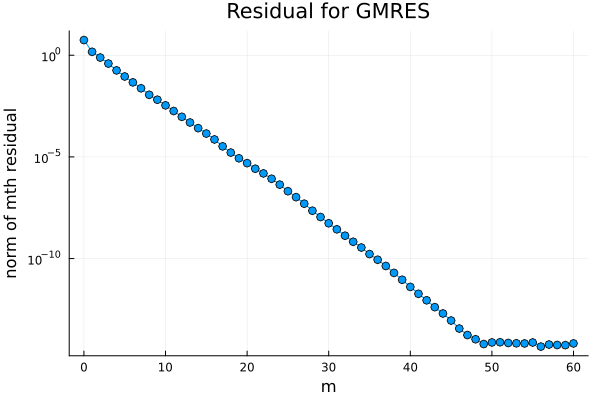

In [27]:
# approximations converge smoothly, practically all the way to machine epsilon
plot(0:60,resid,m=:o,
    xaxis=("m"),yaxis=(:log10,"norm of mth residual"), 
    title="Residual for GMRES",leg=:none)

. . .

Using Arnoldi avoids the instability created by the poor Krylov basis in the other demo.

---

In [28]:
"""
    gmres(A,b,m)

Do `m` iterations of GMRES for the linear system `A`*x=`b`. Returns
the final solution estimate x and a vector with the history of
residual norms. (This function is for demo only, not practical use.)
"""
function gmres(A,b,m)
    n = length(b)
    Q = zeros(n,m+1)
    Q[:,1] = b/norm(b)
    H = zeros(m+1,m)

    # Initial solution is zero.
    x = 0
    residual = [norm(b);zeros(m)]

    for j in 1:m
        # Next step of Arnoldi iteration.
        v = A*Q[:,j]
        for i in 1:j
            H[i,j] = dot(Q[:,i],v)
            v -= H[i,j]*Q[:,i]
        end
        H[j+1,j] = norm(v)
        Q[:,j+1] = v/H[j+1,j]

        # Solve the minimum residual problem.
        r = [norm(b); zeros(j)]
        z = H[1:j+1,1:j] \ r
        x = Q[:,1:j]*z
        residual[j+1] = norm( A*x - b )
    end
    return x,residual
end

gmres

## Convergence and restarting

Minimization of $\|\mathbf{b}-\mathbf{A}\mathbf{x}\|$ over $\mathcal{K}_{m+1}$ includes minimization over $\mathcal{K}_m$. Hence the norm of the residual $\mathbf{r}_m = \mathbf{b} - \mathbf{A}\mathbf{x}_m$ (being the minimized quantity) cannot increase as the iteration unfolds.

. . .

Unfortunately, making other conclusive statements about the convergence of GMRES is neither easy nor simple. The previous demo shows the cleanest behavior: essentially linear convergence down to the range of machine epsilon. But it is possible for the convergence to go through phases of sublinear and superlinear convergence as well. There is a strong dependence on the eigenvalues of the matrix.

. . .

As $m$ grows, the number of entries in $\mathbf{H}_m$ and the number of columns in $\mathbf{Q}_m$ grow quadratically, which can be prohibitive.  For this reason, GMRES is often used with **restarting**.

. . .

Suppose $\hat{\mathbf{x}}$ is an approximate solution of $\mathbf{A}\mathbf{x}=\mathbf{b}$. Then if we set $\mathbf{x}=\mathbf{u}+\hat{\mathbf{x}}$, we have $\mathbf{A}(\mathbf{u}+\hat{\mathbf{x}}) = \mathbf{b}$, or $\mathbf{A}\mathbf{u} = \mathbf{b} - \mathbf{A}\hat{\mathbf{x}}$. The conclusion is that if we get an approximate solution and compute its residual $\mathbf{r}=\mathbf{b} - \mathbf{A}\hat{\mathbf{x}}$, then we need only to solve $\mathbf{A}\mathbf{u} = \mathbf{r}$ in order to get a correction to $\hat{\mathbf{x}}$.

---

Restarting guarantees a fixed upper bound on the per-iteration cost of GMRES. However, this benefit comes at a price. Even though restarting preserves progress made in previous iterations, the Krylov space information is discarded and the residual minimization process starts again over low-dimensional spaces. That can slow or stall the convergence.

. . .

In [30]:
# | echo: false
using FundamentalsNumericalComputation
import Pkg; Pkg.add("IterativeSolvers")
using IterativeSolvers

[ Info: verify download of index files...
[ Info: reading database


EOFError()


┌ Warning: recreating database file
└ @ MatrixDepot ~/.julia/packages/MatrixDepot/4S7Oa/src/download.jl:59
[ Info: reading index files
[ Info: adding metadata...
[ Info: adding svd data...
[ Info: writing database
┌ Warning: exception during initialization: 'KeyError(MatrixDepot)'
└ @ MatrixDepot ~/.julia/packages/MatrixDepot/4S7Oa/src/MatrixDepot.jl:125
    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
    Updating `~/.julia/environments/v1.11/Project.toml`
  [42fd0dbc] + IterativeSolvers v0.9.4
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


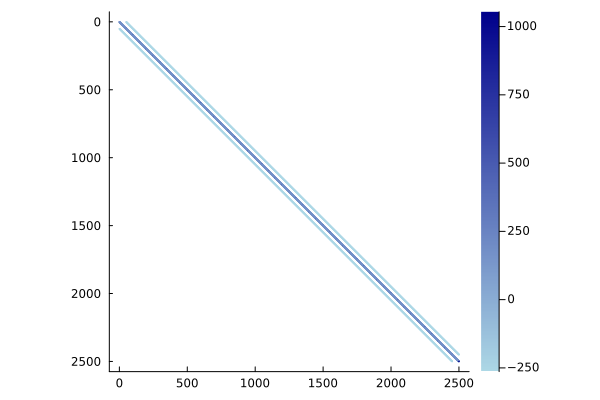

In [31]:
# this matrix results from a discretization of a PDE
A = FNC.poisson(50)
n = size(A,1)
b = ones(n);
spy(A,color=:blues)

---

We compare unrestarted GMRES with three different thresholds for restarting.

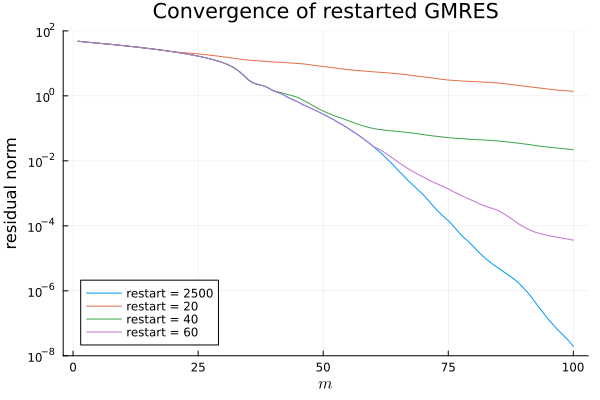

In [32]:
reltol = 1e-12;
plt = plot(title="Convergence of restarted GMRES",leg=:bottomleft,
    xaxis=(L"m"), yaxis=(:log10,"residual norm",[1e-8,100]))

for restart in [n,20,40,60]
    x,hist = IterativeSolvers.gmres(A,b;restart,reltol,
                                    maxiter=100,log=true)
    plot!(hist[:resnorm],label="restart = $restart")
end

plt

. . .

The "pure" GMRES curve is the lowest one. All of the other curves agree with it until the first restart. Decreasing the restart value makes the convergence per iteration generally worse, but the time required per iteration smaller as well.

---

Restarting creates a tradeoff between the number of iterations and the speed per iteration. It's essentially impossible in general to predict the ideal restart location in any given problem, so one goes by experience and hopes for the best.

<!--
[verbose test]{.content-hidden when-format="revealjs" when-format="pptx"}

::: {.callout-caution icon=false}
## Exercise: 

:::

<details><summary>Answer:</summary> </details>


::: {.callout-note icon=false}
## Definition: 
 
:::


::: {.callout-tip icon=false}
## Note: 
 
:::
-->